# Strategy Expansion 03 - Method-specific strategy variants

This notebook shows the core tutorial point: different decomposition methods and windows create different strategies because they produce different trend, cycle, and residual components. The trading rule is held mostly fixed; the decomposition front-end changes the signal.

## Strategy map

The notebook runs five decomposition-based strategy families:

- trend following from decomposed trend;
- oscillation reversion from residual z-score;
- residual Bollinger bands around trend + cycle fair value;
- MACD computed on the decomposed trend;
- dual-EMA crossover computed on the decomposed trend.

Each method/period/window combination is treated as one strategy variant.

In [1]:
import matplotlib.pyplot as plt

from quant_trading.data import load_sample_goog_ohlcv
from quant_trading.strategy_lab import execution_price_panel
from quant_trading.strategy_method_variants import (
    DecompositionVariantSpec,
    collect_orders_and_trades,
    run_method_variant_grid,
)

In [2]:
ohlcv = load_sample_goog_ohlcv(trim_start='2014-01-01')
symbol = 'GOOG'
close = ohlcv['Close'].rename(symbol).to_frame()
volume = ohlcv['Volume'].rename(symbol).to_frame()
execution_prices = execution_price_panel(ohlcv, field='Open', next_bar=True)
execution_prices.columns = [symbol]

close.tail()

,GOOG
Date,
2017-12-26,1056.739990
2017-12-27,1049.369995
2017-12-28,1048.140015
2017-12-29,1046.400024
2018-01-02,1065.000000


## Build a compact method grid

The grid below is intentionally small for a notebook. A full research run can add periods 63/126/252, shorter steps, and optional Wavelet/EMD/VMD variants. The default grid avoids very short periods so the extracted components read as market structure rather than one-month noise.


In [3]:
specs = [
    DecompositionVariantSpec('STL', period=126, train_window=504, step=21, z_window=63, role='fixed_period_half_year_cycle'),
    DecompositionVariantSpec('SSA', period=126, train_window=504, step=21, z_window=63, role='subspace_half_year_cycle'),
    DecompositionVariantSpec('STD', period=126, train_window=504, step=21, z_window=63, role='dispersion_half_year_cycle'),
]

stats, results, spec_table, coverage, failed = run_method_variant_grid(
    close,
    volume,
    specs=specs,
    execution_prices=execution_prices,
    allow_short_trend=False,
    allow_short_reversion=True,
)

stats.head(20)


,strategy,strategy_family,decomposition_variant,total_return,cagr,sharpe,max_drawdown,calmar,volatility,hit_rate,...,periods_per_year,execution_model,spec_method,spec_period,spec_train_window,spec_step,spec_z_window,spec_label,spec_role,spec_name
0,detime_SSA_p126_tw504_s21_trend_macd,trend_macd,SSA_p126_tw504_s21,0.365531,0.080999,1.525011,-0.052530,1.541967,0.051964,0.088294,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,SSA,126,504,21,63,None,subspace_half_year_cycle,SSA_p126_tw504_s21
1,detime_SSA_p126_tw504_s21_trend_crossover,trend_crossover,SSA_p126_tw504_s21,0.347427,0.077398,0.978572,-0.084043,0.920942,0.079416,0.152778,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,SSA,126,504,21,63,None,subspace_half_year_cycle,SSA_p126_tw504_s21
2,detime_SSA_p126_tw504_s21_residual_bollinger,residual_bollinger,SSA_p126_tw504_s21,0.120124,0.028766,0.542894,-0.071692,0.401241,0.055008,0.053571,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,SSA,126,504,21,63,None,subspace_half_year_cycle,SSA_p126_tw504_s21
3,detime_STL_p126_tw504_s21_hybrid_regime,hybrid_regime,STL_p126_tw504_s21,0.051462,0.012624,0.537848,-0.025492,0.495222,0.023848,0.009921,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,STL,126,504,21,63,None,fixed_period_half_year_cycle,STL_p126_tw504_s21
4,detime_STL_p126_tw504_s21_oscillation_reversion,oscillation_reversion,STL_p126_tw504_s21,0.051462,0.012624,0.537848,-0.025492,0.495222,0.023848,0.009921,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,STL,126,504,21,63,None,fixed_period_half_year_cycle,STL_p126_tw504_s21
5,detime_STL_p126_tw504_s21_trend_crossover,trend_crossover,STL_p126_tw504_s21,0.173953,0.040909,0.419117,-0.133557,0.306303,0.110303,0.193452,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,STL,126,504,21,63,None,fixed_period_half_year_cycle,STL_p126_tw504_s21
6,detime_SSA_p126_tw504_s21_oscillation_reversion,oscillation_reversion,SSA_p126_tw504_s21,0.020514,0.005090,0.415414,-0.017531,0.290325,0.012406,0.008929,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,SSA,126,504,21,63,None,subspace_half_year_cycle,SSA_p126_tw504_s21
7,detime_SSA_p126_tw504_s21_hybrid_regime,hybrid_regime,SSA_p126_tw504_s21,0.020514,0.005090,0.415414,-0.017531,0.290325,0.012406,0.008929,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,SSA,126,504,21,63,None,subspace_half_year_cycle,SSA_p126_tw504_s21
8,detime_STL_p126_tw504_s21_trend_macd,trend_macd,STL_p126_tw504_s21,0.056238,0.013772,0.228508,-0.152319,0.090418,0.071101,0.062500,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,STL,126,504,21,63,None,fixed_period_half_year_cycle,STL_p126_tw504_s21
9,detime_STL_p126_tw504_s21_residual_bollinger,residual_bollinger,STL_p126_tw504_s21,0.019034,0.004725,0.137965,-0.065186,0.072482,0.039841,0.015873,...,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy,STL,126,504,21,63,None,fixed_period_half_year_cycle,STL_p126_tw504_s21


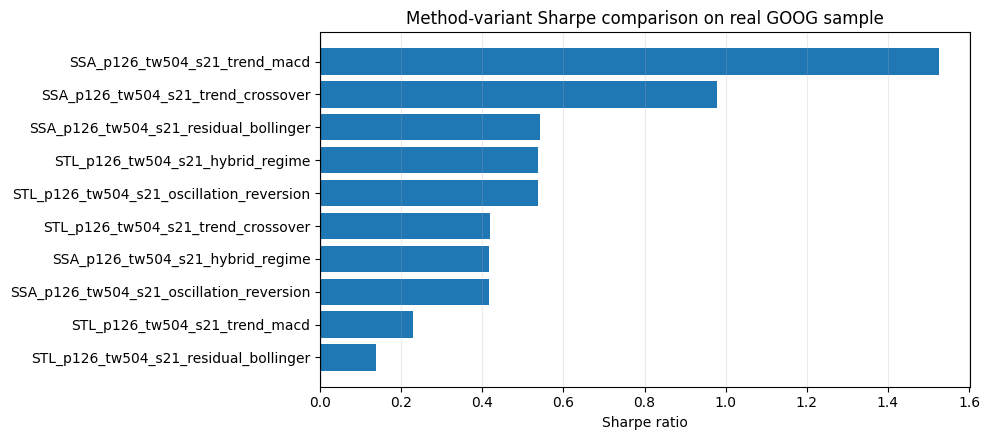

In [4]:
plot_stats = stats.sort_values("sharpe", ascending=True).tail(10).copy()
labels = plot_stats["strategy"].astype(str).str.replace("detime_", "", regex=False)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(labels, plot_stats["sharpe"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Sharpe ratio")
ax.set_title("Method-variant Sharpe comparison on real GOOG sample")
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [5]:
orders, trades = collect_orders_and_trades(results)
print('orders:', len(orders))
print('round-trip trades:', len(trades))
trades.head()

orders: 67
round-trip trades: 32


,strategy,asset,side,entry_signal_date,entry_fill_date,exit_signal_date,exit_fill_date,entry_price,exit_price,bars_held,entry_weight,directional_return,approx_weighted_return_after_cost
0,detime_STL_p126_tw504_s21_oscillation_reversion,GOOG,short,2017-06-02,2017-06-05,2017-07-03,2017-07-05,976.549988,901.760010,21,-0.677286,0.076586,0.051396
1,detime_STL_p126_tw504_s21_hybrid_regime,GOOG,short,2017-06-02,2017-06-05,2017-07-03,2017-07-05,976.549988,901.760010,21,-0.677286,0.076586,0.051396
2,detime_STL_p126_tw504_s21_residual_bollinger,GOOG,short,2017-05-03,2017-05-04,2017-07-03,2017-07-05,926.070007,901.760010,42,-1.000000,0.026251,0.025551
3,detime_STL_p126_tw504_s21_trend_macd,GOOG,long,2016-02-02,2016-02-03,2016-02-23,2016-02-24,770.219971,688.919983,14,1.000000,-0.105554,-0.106254
4,detime_STL_p126_tw504_s21_trend_macd,GOOG,long,2016-04-04,2016-04-05,2016-04-22,2016-04-25,738.000000,716.099976,14,1.000000,-0.029675,-0.030375


In [6]:
coverage.groupby(['method', 'variant', 'feature'])['coverage'].max().reset_index().head(20)

,method,variant,feature,coverage
0,SSA,SSA_p126_tw504_s21,component_stability,0.500992
1,SSA,SSA_p126_tw504_s21,cycle,0.500992
2,SSA,SSA_p126_tw504_s21,cycle_amplitude,0.500992
3,SSA,SSA_p126_tw504_s21,cycle_position,0.500992
4,SSA,SSA_p126_tw504_s21,cycle_slope,0.500992
5,SSA,SSA_p126_tw504_s21,cycle_turn_up,0.500992
6,SSA,SSA_p126_tw504_s21,cycle_z,0.500992
7,SSA,SSA_p126_tw504_s21,reconstruction_error,0.500992
8,SSA,SSA_p126_tw504_s21,residual,0.500992
9,SSA,SSA_p126_tw504_s21,residual_abs_z,0.500992


## Parameter interpretation

- `period` is the assumed cycle length. It plays a similar role to an indicator window.
- `train_window` controls how much recent history the decomposition sees. Short windows adapt quickly; long windows produce smoother components.
- `step` controls how often the decomposition is recomputed in walk-forward mode. Smaller steps are more responsive and more expensive.
- `z_window` controls residual normalization and residual-band sensitivity.